## Bar Chart

A bar chart is a way of displaying data using rectangular bars, where the length (or height) of each bar represents a value  like a count, total, or measurement. Each bar corresponds to a category (like a weather condition, a product name, a month, etc.), and the longer the bar, the larger the value.

Bar charts are used to compare quantities across different categories at a glance.

## Vertical Bar Chart

- Bars go up from the bottom (standing vertically)
- Categories are listed along the x-axis (horizontal)
- Values are measured along the y-axis (vertical)
- Created in matplotlib with `axes.bar()`
- Good for a small number of categories with short labels, since long labels often need to be rotated to fit
- Example: your very first chart, where weather conditions had to be tilted 45° along the bottom

## Horizontal Bar Chart

- Bars go  sideways from the left (lying horizontally)
- Categories are listed along the y-axis (vertical)
- Values are measured along the x-axis (horizontal)
- Created in matplotlib with `axes.barh()`
- Good for categories with **long text labels** (like "Rain Showers" or "Drizzle,Fog"), since the labels stay horizontal and readable without rotation
- Easier to scan as a ranked list, top to bottom



In [2]:
import pandas as pd, numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

In [3]:
df = pd.read_csv(r'C:\Users\admin\Desktop\pydata\weather_2012 (1).csv')


In [7]:
df.head()

,Date/Time,Temp (C),Dew Point Temp (C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [6]:
df.head(5)

,Date/Time,Temp (C),Dew Point Temp (C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Weather
0,2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [ ]:
print(df.columns.tolist())   # check the columns namesfindfont

['Date/Time', 'Temp (C)', 'Dew Point Temp (C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'Weather']


## Vertical Barchart

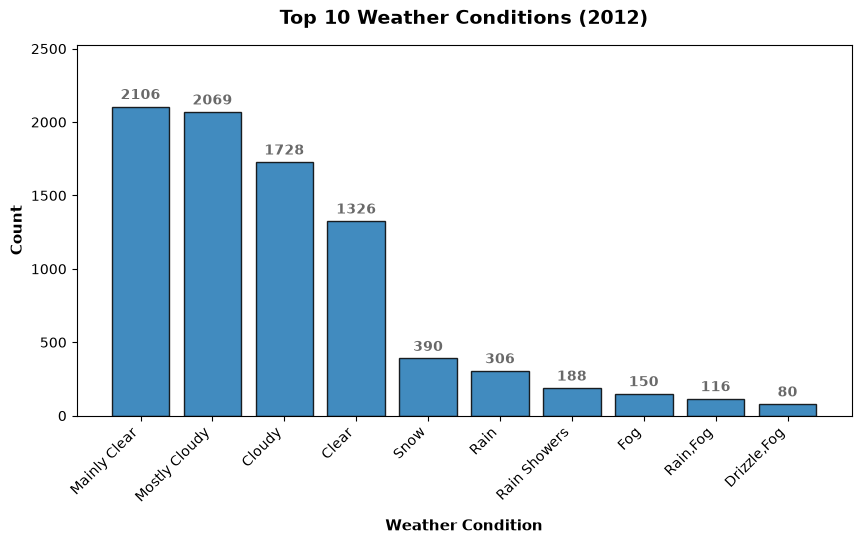

In [12]:
# Grabbing the top 10 most common weather types
top_weather = df['Weather'].value_counts().head(10)

fig, axes = plt.subplots(figsize=(10, 7))

# Create a styled vertical bar chart
bars = axes.bar(top_weather.index, top_weather.values, color="tab:blue", edgecolor="black", alpha=0.85)


# Titles and labels
axes.set_title('Top 10 Weather Conditions (2012)', fontsize=14, fontweight='bold', pad=15)
axes.set_xlabel('Weather Condition', fontsize=11, fontweight='bold', labelpad=10)
axes.set_ylabel('Count', fontsize=11, fontweight='bold')

# Automatically add the exact value count on top of EVERY bar
axes.bar_label(bars, padding=3, fontsize=10, fontweight='bold', color="dimgray")

# Rotate x-axis labels so they are readable
plt.xticks(rotation=45, ha='right', fontsize=10)

# Adding extra headroom at the top so the numbers aren't cut off
axes.set_ylim(0, max(top_weather.values) * 1.2)

# Giving extra bottom margin so the rotated weather names are fully visible
plt.subplots_adjust(bottom=0.35)

plt.show()

## Key observations:
- The top 4 conditions (Mainly Clear, Mostly Cloudy, Cloudy, Clear) make up the large majority of all recorded readings.
- There's a sharp drop-off after "Clear" — precipitation-related conditions (Snow, Rain, Fog, etc.) are far less frequent.
- Compound conditions like "Rain, Fog" and "Drizzle, Fog" represent hours where multiple conditions were logged simultaneously.
- This distribution is consistent with a temperate climate, where clear/cloudy sky states are logged more often than active precipitation events.

:Padding in your matplotlib code refers to extra space added between an element and whatever is next to it, so things don't look overlapped.





## Horizontal Barchart

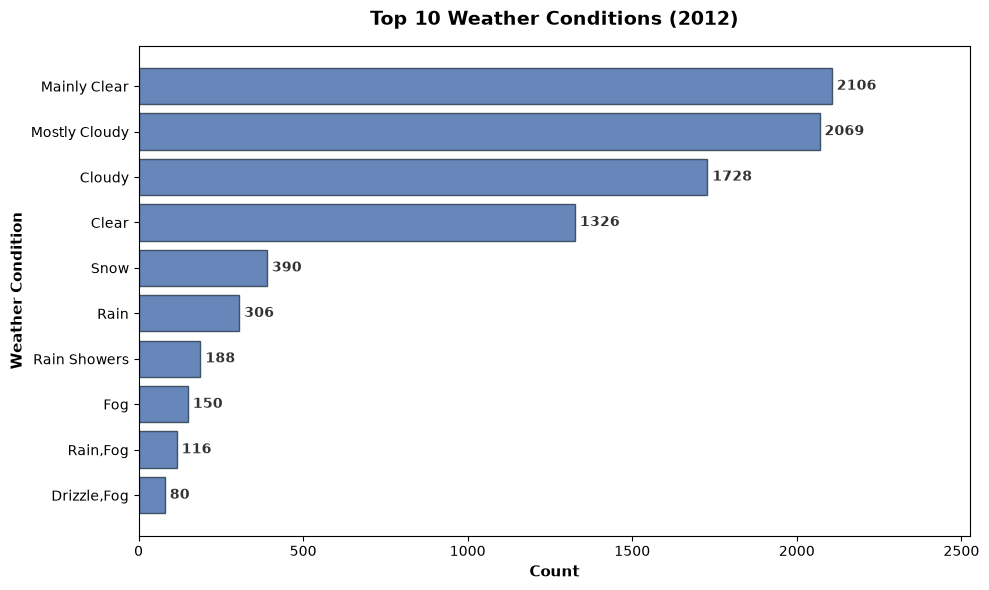

In [21]:
# Grab the top 10 most common weather types and sort them for a clean horizontal layout
top_weather = df['Weather'].value_counts().head(10).sort_values(ascending=True)

fig, axes = plt.subplots(figsize=(10, 6))

# Create a styled horizontal bar chart
bars = axes.barh(top_weather.index, top_weather.values, color='#4c72b0', edgecolor='#2c3e50', alpha=0.85)

# Titles and labels
axes.set_title('Top 10 Weather Conditions (2012)', fontsize=14, fontweight='bold', pad=15)
axes.set_xlabel('Count', fontsize=11, fontweight='bold')
axes.set_ylabel('Weather Condition', fontsize=11, fontweight='bold')

# Add exact count numbers next to each bar for extra polish
[axes.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2, 
f'{int(bar.get_width())}', va='center', ha='left', fontsize=10, fontweight='semibold', color='#333333')
for bar in bars]

# Adding extra headroom at the top so the numbers aren't cut off
axes.set_xlim(0, max(top_weather.values) * 1.2)


# Clean layout spacing
plt.tight_layout()
plt.show()